# Random Forest Cleassificer과 여러가지 matric을 이용해서 모델의 성능 평가

In [1]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem

In [28]:
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import MolFromSmiles
from rdkit.Chem.GraphDescriptors import (BalabanJ, BertzCT, Chi0, Chi0n, Chi0v, Chi1,
                                         Chi1n, Chi1v, Chi2n, Chi2v, Chi3n, Chi3v, Chi4n, Chi4v,
                                         HallKierAlpha, Ipc, Kappa1, Kappa2, Kappa3)

from rdkit.Chem.EState.EState_VSA import (EState_VSA1, EState_VSA10, EState_VSA11, EState_VSA2, EState_VSA3,
                                          EState_VSA4, EState_VSA5, EState_VSA6, EState_VSA7, EState_VSA8, EState_VSA9,
                                          VSA_EState1, VSA_EState10, VSA_EState2, VSA_EState3, VSA_EState4, VSA_EState5,
                                          VSA_EState6, VSA_EState7, VSA_EState8, VSA_EState9,)

from rdkit.Chem.Descriptors import (ExactMolWt, MolWt, HeavyAtomMolWt, MaxAbsPartialCharge, MinPartialCharge,
                                    MaxPartialCharge, MinAbsPartialCharge, NumRadicalElectrons, NumValenceElectrons)

from rdkit.Chem.EState.EState import (MaxAbsEStateIndex, MaxEStateIndex, MinAbsEStateIndex, MinEStateIndex,)

from rdkit.Chem.Lipinski import (FractionCSP3, HeavyAtomCount, NHOHCount, NOCount, NumAliphaticCarbocycles,
                                 NumAliphaticHeterocycles, NumAliphaticRings, NumAromaticCarbocycles, NumAromaticHeterocycles,
                                 NumAromaticRings, NumHAcceptors, NumHDonors, NumHeteroatoms, RingCount,
                                 NumRotatableBonds, NumSaturatedCarbocycles, NumSaturatedHeterocycles, NumSaturatedRings,)

from rdkit.Chem.Crippen import (MolLogP, MolMR, )

from rdkit.Chem.MolSurf import (LabuteASA, PEOE_VSA1, PEOE_VSA10, PEOE_VSA11, PEOE_VSA12, PEOE_VSA13, PEOE_VSA14,
                                PEOE_VSA2, PEOE_VSA3,PEOE_VSA4, PEOE_VSA5, PEOE_VSA6, PEOE_VSA7, PEOE_VSA8, PEOE_VSA9,
                                SMR_VSA1, SMR_VSA10, SMR_VSA2, SMR_VSA3, SMR_VSA4, SMR_VSA5, SMR_VSA6,
                                SMR_VSA7, SMR_VSA8, SMR_VSA9, SlogP_VSA1, SlogP_VSA10, SlogP_VSA11, SlogP_VSA12,
                                SlogP_VSA2, SlogP_VSA3,SlogP_VSA4, SlogP_VSA5, SlogP_VSA6, SlogP_VSA7, SlogP_VSA8,
                                SlogP_VSA9, TPSA, )

from rdkit.Chem.Fragments import (fr_Al_COO, fr_Al_OH, fr_Al_OH_noTert, fr_ArN, fr_Ar_COO, fr_Ar_N, fr_Ar_NH,
 fr_Ar_OH, fr_COO, fr_COO2, fr_C_O, fr_C_O_noCOO, fr_C_S, fr_HOCCN, fr_Imine, fr_NH0, fr_NH1,
 fr_NH2, fr_N_O, fr_Ndealkylation1, fr_Ndealkylation2, fr_Nhpyrrole, fr_SH, fr_aldehyde, fr_alkyl_carbamate,
 fr_alkyl_halide, fr_allylic_oxid, fr_amide, fr_amidine, fr_aniline, fr_aryl_methyl, fr_azide, fr_azo, fr_barbitur,
 fr_benzene, fr_benzodiazepine, fr_bicyclic, fr_diazo, fr_dihydropyridine, fr_epoxide, fr_ester, fr_ether, fr_furan,
 fr_guanido, fr_halogen, fr_hdrzine, fr_hdrzone, fr_imidazole, fr_imide, fr_isocyan, fr_isothiocyan, fr_ketone,
 fr_ketone_Topliss, fr_lactam, fr_lactone, fr_methoxy, fr_morpholine, fr_nitrile, fr_nitro, fr_nitro_arom,
 fr_nitro_arom_nonortho, fr_nitroso, fr_oxazole, fr_oxime, fr_para_hydroxylation, fr_phenol,
 fr_phenol_noOrthoHbond, fr_phos_acid, fr_phos_ester, fr_piperdine, fr_piperzine, fr_priamide, fr_prisulfonamd,
 fr_pyridine, fr_quatN, fr_sulfide, fr_sulfonamd, fr_sulfone, fr_term_acetylene, fr_tetrazole, fr_thiazole, fr_thiocyan,
 fr_thiophene, fr_unbrch_alkane, fr_urea)

# Descriptor 계산 수행 함수. 
def calc_descriptors(mol):
    if mol is None:
        print("Molecule is None!")
        return None
    else:
        AllChem.ComputeGasteigerCharges(mol)
        finger = [
            BalabanJ(mol) , # 0
            BertzCT(mol) , # 1
            Chi0(mol) , # 2
            Chi0n(mol) , # 3
            Chi0v(mol) , # 4
            Chi1(mol) , # 5
            Chi1n(mol) , # 6
            Chi1v(mol) , # 7
            Chi2n(mol) ,
            Chi2v(mol) ,
            Chi3n(mol) ,
            Chi3v(mol) ,
            Chi4n(mol) ,
            Chi4v(mol) ,
            EState_VSA1(mol) ,
            EState_VSA10(mol) ,
            EState_VSA11(mol) ,
            EState_VSA2(mol) ,
            EState_VSA3(mol) ,
            EState_VSA4(mol) ,
            EState_VSA5(mol) ,
            EState_VSA6(mol) ,
            EState_VSA7(mol) ,
            EState_VSA8(mol) ,
                EState_VSA9(mol) ,
                ExactMolWt(mol) ,
                FractionCSP3(mol) ,
                HallKierAlpha(mol) ,
                HeavyAtomCount(mol) ,
                HeavyAtomMolWt(mol) ,
                # Ipc(mol) ,
                Kappa1(mol) ,
                Kappa2(mol) ,
                Kappa3(mol) ,
                LabuteASA(mol) ,
                MaxAbsEStateIndex(mol) ,
                MaxAbsPartialCharge(mol) ,
                MaxEStateIndex(mol) ,
                MaxPartialCharge(mol) ,
                MinAbsEStateIndex(mol) ,
                MinAbsPartialCharge(mol) ,
                MinEStateIndex(mol) ,
                MinPartialCharge(mol) ,
                MolLogP(mol) ,
                MolMR(mol) ,
                MolWt(mol) ,
                NHOHCount(mol) ,
                NOCount(mol) ,
                NumAliphaticCarbocycles(mol) ,
                NumAliphaticHeterocycles(mol) ,
                NumAliphaticRings(mol) ,
                NumAromaticCarbocycles(mol) ,
                NumAromaticHeterocycles(mol) ,
                NumAromaticRings(mol) ,
                NumHAcceptors(mol) ,
                NumHDonors(mol) ,
                NumHeteroatoms(mol) ,
                NumRadicalElectrons(mol) ,
                NumRotatableBonds(mol) ,
                NumSaturatedCarbocycles(mol) ,
                NumSaturatedHeterocycles(mol) ,
                NumSaturatedRings(mol) ,
                NumValenceElectrons(mol) ,
                PEOE_VSA1(mol) ,
                PEOE_VSA10(mol) ,
                PEOE_VSA11(mol) ,
                PEOE_VSA12(mol) ,
                PEOE_VSA13(mol) ,
                PEOE_VSA14(mol) ,
                PEOE_VSA2(mol) ,
                PEOE_VSA3(mol) ,
                PEOE_VSA4(mol) ,
                PEOE_VSA5(mol) ,
                PEOE_VSA6(mol) ,
                PEOE_VSA7(mol) ,
                PEOE_VSA8(mol) ,
                PEOE_VSA9(mol) ,
                RingCount(mol) ,
                SMR_VSA1(mol) ,
                SMR_VSA10(mol) ,
                SMR_VSA2(mol) ,
                SMR_VSA3(mol) ,
                SMR_VSA4(mol) ,
                SMR_VSA5(mol) ,
                SMR_VSA6(mol) ,
                SMR_VSA7(mol) ,
                SMR_VSA8(mol) ,
                SMR_VSA9(mol) ,
                SlogP_VSA1(mol) ,
                SlogP_VSA10(mol) ,
                SlogP_VSA11(mol) ,
                SlogP_VSA12(mol) ,
                SlogP_VSA2(mol) ,
                SlogP_VSA3(mol) ,
                SlogP_VSA4(mol) ,
                SlogP_VSA5(mol) ,
                SlogP_VSA6(mol) ,
                SlogP_VSA7(mol) ,
                SlogP_VSA8(mol) ,
                SlogP_VSA9(mol) ,
                TPSA(mol) ,
                VSA_EState1(mol) ,
                VSA_EState10(mol) ,
                VSA_EState2(mol) ,
                VSA_EState3(mol) ,
                VSA_EState4(mol) ,
                VSA_EState5(mol) ,
                VSA_EState6(mol) ,
                VSA_EState7(mol) ,
                VSA_EState8(mol) ,
                VSA_EState9(mol) ,
                fr_Al_COO(mol) ,
                fr_Al_OH(mol) ,
                fr_Al_OH_noTert(mol) ,
                fr_ArN(mol) ,
                fr_Ar_COO(mol) ,
                fr_Ar_N(mol) ,
                fr_Ar_NH(mol) ,
                fr_Ar_OH(mol) ,
                fr_COO(mol) ,
                fr_COO2(mol) ,
                fr_C_O(mol) ,
                fr_C_O_noCOO(mol) ,
                fr_C_S(mol) ,
                fr_HOCCN(mol) ,
                fr_Imine(mol) ,
                fr_NH0(mol) ,
                fr_NH1(mol) ,
                fr_NH2(mol) ,
                fr_N_O(mol) ,
                fr_Ndealkylation1(mol) ,
                fr_Ndealkylation2(mol) ,
                fr_Nhpyrrole(mol) ,
                fr_SH(mol) ,
                fr_aldehyde(mol) ,
                fr_alkyl_carbamate(mol) ,
                fr_alkyl_halide(mol) ,
                fr_allylic_oxid(mol) ,
                fr_amide(mol) ,
                fr_amidine(mol) ,
                fr_aniline(mol) ,
                fr_aryl_methyl(mol) ,
                fr_azide(mol) ,
                fr_azo(mol) ,
                fr_barbitur(mol) ,
                fr_benzene(mol) ,
                fr_benzodiazepine(mol) ,
                fr_bicyclic(mol) ,
                fr_diazo(mol) ,
                fr_dihydropyridine(mol) ,
                fr_epoxide(mol) ,
                fr_ester(mol) ,
                fr_ether(mol) ,
                fr_furan(mol) ,
                fr_guanido(mol) ,
                fr_halogen(mol) ,
                fr_hdrzine(mol) ,
                fr_hdrzone(mol) ,
                fr_imidazole(mol) ,
                fr_imide(mol) ,
                fr_isocyan(mol) ,
                fr_isothiocyan(mol) ,
                fr_ketone(mol) ,
                fr_ketone_Topliss(mol) ,
                fr_lactam(mol) ,
                fr_lactone(mol) ,
                fr_methoxy(mol) ,
                fr_morpholine(mol) ,
                fr_nitrile(mol) ,
                fr_nitro(mol) ,
                fr_nitro_arom(mol) ,
                fr_nitro_arom_nonortho(mol) ,
                fr_nitroso(mol) ,
                fr_oxazole(mol) ,
                fr_oxime(mol) ,
                fr_para_hydroxylation(mol) ,
                fr_phenol(mol) ,
                fr_phenol_noOrthoHbond(mol) ,
                fr_phos_acid(mol) ,
                fr_phos_ester(mol) ,
                fr_piperdine(mol) ,
                fr_piperzine(mol) ,
                fr_priamide(mol) ,
                fr_prisulfonamd(mol) ,
                fr_pyridine(mol) ,
                fr_quatN(mol) ,
                fr_sulfide(mol) ,
                fr_sulfonamd(mol) ,
                fr_sulfone(mol) ,
                fr_term_acetylene(mol) ,
                fr_tetrazole(mol) ,
                fr_thiazole(mol) ,
                fr_thiocyan(mol) ,
                fr_thiophene(mol),
                fr_unbrch_alkane(mol) ,
                fr_urea(mol) , #rdkit properties # 196
                ]
        return finger

## Pandas 불러오기

In [4]:
import pandas as pd

In [5]:
dat = pd.read_csv("data/jak2_data.csv")

In [6]:
dat

,SMILES,pIC50
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59
...,...,...
1906,CC(=O)N1CCCCC(Nc2ncccc2-c2cnc3[nH]ccc3n2)C1,10.72
1907,CN1CCN(c2ncc(-c3cnc4[nH]ccc4n3)c(NC3CCCN(S(=O)...,10.76
1908,CC1CN(S(=O)(=O)CC2CCC(N(C)c3[nH]cnc4nccc3-4)CC...,10.78
1909,CS(=O)(=O)N1CCC(Nc2ncccc2-c2cnc3[nH]ccc3n2)C1,10.97


In [10]:
# Pandas의 기본 자료구조는 DataFrame 이라는 Class
type(dat)

pandas.core.frame.DataFrame

### describe라는 메소드를 이용하면 data의 각 column의 기본 통계치를 알 수 있다.

In [7]:
dat.describe()

,pIC50
count,1911.000000
mean,7.391544
std,1.180905
min,4.260000
25%,6.650000
50%,7.380000
75%,8.100000
max,10.970000


# 예제: ASK1 단백질에 active한 물질을 예측하는 모델 학습

* Active한 물질은 pIC50 > 6 로 정의한다.
* pIC50 = (-log10(IC50)))
* IC50 < 1microM

## 1. 어떤 물질이 acitve인지 정의해야함
* pIC50 Class 갑사이 6보다 크면 True, 6보다 작으면 적으면 False로 정의한다.

In [12]:
# Pandas 데이터 프레임에서 특정 column을 선택할 때는 column의 이름을 정해야한다.
active = dat["pIC50"] > 6

In [14]:
print (active)

0       False
1       False
2       False
3       False
4       False
        ...  
1906     True
1907     True
1908     True
1909     True
1910     True
Name: pIC50, Length: 1911, dtype: bool


In [17]:
# Pandas의 Series라고 하는 class로 정의됨.
type(active)

pandas.core.series.Series

## 2. Input feature matrix 만들기

### 2-1. SMILES -> Mol로 변환

### Troubleshooting
> for 문과 if 문은 첫줄에 ':' 가 포함된다.

In [19]:
mol_list = []   # mol type 변수를 저장할 비어있는 리스트
for smi in dat["SMILES"]:
    m = Chem.MolFromSmiles(mol)
    if m is not None:   # 실제 유효한 분자라면
    mol_list.append(mol)

SyntaxError: expected ':' (1192990007.py, line 4)

In [23]:
mol_list = []   # mol type 변수를 저장할 비어있는 리스트
for smi in dat["SMILES"]:
    m = Chem.MolFromSmiles(smi)
    if m is not None:   # 실제 유효한 분자라면
        mol_list.append(m)

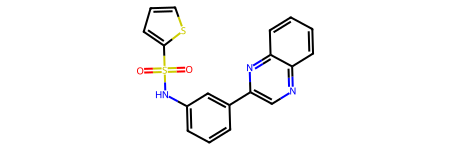

In [24]:
mol_list[0]

In [25]:
len(mol_list)

1911

=> 1911개의 분자가 성공적으로 변환이 되었다

### 2-2. Mol -> descriptor로 변환

In [30]:
desc_list = []
for m in mol_list:
    desc_list.append(calc_descriptors(m))

In [31]:
desc_list[0]

[1.6891010679640355,
 1139.9346654410272,
 17.27781011412252,
 12.955623583130881,
 14.588616744986334,
 12.116122967884975,
 7.503161722513579,
 9.865977781362865,
 5.3623467315570865,
 8.219283427004692,
 3.619036345691878,
 6.39779902625805,
 2.460132737297642,
 4.502492141959249,
 10.023291153407584,
 8.417796984328938,
 0.0,
 4.2091791775220795,
 11.381314269532023,
 16.59685292692952,
 11.336785877934737,
 41.90874168438704,
 30.33183534230805,
 14.690051906346504,
 0.0,
 367.04491865600005,
 0.0,
 -2.769999999999999,
 25,
 354.35100000000006,
 15.740008044893049,
 6.268385354767415,
 3.2392829946811608,
 148.61755337168788,
 12.35664883780775,
 0.27894233829193016,
 12.35664883780775,
 0.2708926724876687,
 0.28092580576256654,
 0.2708926724876687,
 -3.571131744721662,
 -0.27894233829193016,
 4.159100000000002,
 100.10150000000002,
 367.4550000000001,
 1,
 5,
 0,
 0,
 0,
 2,
 2,
 4,
 5,
 1,
 7,
 0,
 4,
 0,
 0,
 0,
 124,
 0.0,
 4.2091791775220795,
 0.0,
 0.0,
 10.023291153407584,


In [32]:
len(desc_list[0])

195

In [33]:
len(desc_list)

1911

=> Mol type 변수들이 descriptor 벡터로 성공적으로 변환하였다.

In [35]:
# descriptor 벡터를 Numpy array로 변환
import numpy as np
X = np.array(desc_list)
print(X.shape)

(1911, 195)


=> X가 1911 X 195의 크기를 가지는 행렬로 변환

### Input feature와 output value 준비 완료

* X가 input feature, acitve가 output이 됨

## 3. Training set과 test set 분리

* train test split 모듈 사용

In [37]:
from sklearn.model_selection import train_test_split

In [39]:
y = active
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [41]:
X_train

array([[1.14570502e+00, 1.08795674e+03, 2.14240745e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.56316812e+00, 1.05771076e+03, 1.86396174e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.34450834e+00, 1.50845500e+03, 2.52858818e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.40127944e+00, 1.51520350e+03, 2.77334756e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.14909257e+00, 1.70333390e+03, 3.08463597e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.61059678e+00, 9.31560103e+02, 1.84764807e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [42]:
X_test.shape

(383, 195)

## 4. RandomForest Classifier 과정

In [46]:
# 4. RandomForest Classifier 불러오기
from sklearn.ensemble import RandomForestClassifier as RFC

In [44]:
# default setting 으로 모델 생성.
my_model = RFC()

In [47]:
# 모델 학습
my_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
# 예측
y_pred = my_model.predict(X_test)

In [49]:
y_pred

array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [50]:
# accuracy, precision, recall, f1, confusion 을 통한 모델 성능 평가

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### 4.1 Confusion matrix 확인

In [53]:
confusion_matrix(y_test, y_pred)

array([[ 15,  27],
       [  7, 334]], dtype=int64)

=> sklearn의 Confusion matrix에서는 행이 실제 값에 해당하고 열이 예측 값에 해당한다.

In [54]:
# 각 행과 열이 어떤 class에 해당하는지 확인.
print(my_model.classes_)

[False  True]


=> 첫번째 행, 첫번째 열은 False에 해당하고 두번째 행과 두번째 열은 True에 해당한다.

=> 위 confusion matrix가 의미하는 바는
TP: 334개, TN: 15개, FP: 27개, FN: 7개 임을 보여준다.

### 4.2 accuracy 확인

In [51]:
accuracy_score(y_test, y_pred)

0.9112271540469974

=> Accuracy = (TP + TN) / Total

### 4.3 Precision 확인

In [55]:
precision_score(y_test, y_pred)

0.925207756232687

### 4.4 recall 확인

In [57]:
recall_score(y_test, y_pred)

0.9794721407624634

### 4.5 F1 score 확인(precision과 recall 만으로는 해석의 오류/오차가 있을 수 있기 때문)

In [58]:
f1_score(y_test, y_pred)

0.9515669515669516

### 4.6. balanced accuracy 확인

> True와 False 데이터의 비율이 많이 차이날때

In [59]:
from sklearn.metrics import balanced_accuracy_score

In [60]:
balanced_accuracy_score (y_test, y_pred)

0.6683074989526603

### 4.7 Matthews_corrcoef(MCC) 확인
> false positive, true positive, true negative, false negative 를 모두 고려한 balanced measured

In [62]:
from sklearn.metrics import matthews_corrcoef as mcc

In [63]:
mcc(y_test, y_pred)

0.4520332231877082

## 5. ROC curve 확인

> ROC 커브 계산을 하기 위해서는 class prediction probability가 필요하다.

>이를 계산하기 위해서 대부분의 sklearn에 존재하는 예측 모델들은 predict_proba 라고 하는 method를 가지고 있다.

+ 추가 설명
ROC 커브는 단순히 "맞다/틀리다"라는 결과가 아니라, 분류 결정 입계값(Threshold)를 0에서 1까지 변화시키면서 모델의 성능을 예측하기 때문.

> 유연성: 만약 모델이 0.51의 확률로 '양성'이라고 했다면, 이는 0.99의 확률로 '양성'이라고 한 것보다 확신이 낮다.

> 성능 측정: 확률값을 알면 임계값을 조 정하며 TPR(재현율)과 FPR(위양성률)의 변화를 추적할 수 있고, 그 궤적을 그린 것이 ROC 커브. 단순 0/1결과만으로는 이 곡선을 그릴 수 없음

In [64]:
from sklearn.metrics import roc_curve

In [78]:
# 모델이 최종적으로 내릴 "결정(Lable)".
# 보통 정확도(Accuracy), 정밀도(Precision), 재현율(recall)을 계산할 때 쓴다.
my_model.predict(X_test)

array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [79]:
# 모델이 각 클래스에 대해 느는 "확신도(Probability)"
# ROC 커브와 AUC를 계산할 때는 이 확률값이 반드시 필요. 
y_score = my_model.predict_proba(X_test)

In [69]:
y_score

array([[0.        , 1.        ],
       [0.78      , 0.22      ],
       [0.        , 1.        ],
       [0.29      , 0.71      ],
       [0.48      , 0.52      ],
       [0.        , 1.        ],
       [0.48      , 0.52      ],
       [0.08      , 0.92      ],
       [0.        , 1.        ],
       [0.02      , 0.98      ],
       [0.11      , 0.89      ],
       [0.36      , 0.64      ],
       [0.08      , 0.92      ],
       [0.83      , 0.17      ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.13      , 0.87      ],
       [0.        , 1.        ],
       [0.07      , 0.93      ],
       [0.01      , 0.99      ],
       [0.28      , 0.72      ],
       [0.15      , 0.85      ],
       [0.05      , 0.95      ],
       [0.62      , 0.38      ],
       [0.34      , 0.66      ],
       [0.19      , 0.81      ],
       [0.73      , 0.27      ],
       [0.04      , 0.96      ],
       [0.        , 1.        ],
       [0.18      , 0.82      ],
       [0.

In [71]:
y_score.shape

(383, 2)

In [73]:
# 이 속성은 모델이 학습 과정에서 마주친 타겟 레이블(클레스)의 종류과 순서를 담고 있음.
# 예) 암 여부를 ['정상', '암']으로 학습했다면 classes_는 [0.1] 또는 해당 문자열 배열을 가짐.
# 중요한 이유: predict_proba가 반환하는 결과의 열(column) 순서가 바로 이 classes_의 순서와 일치 (즉, 첫번째 열이 어떤 클래스의 확률인지 확인하려면 이 속성을 봐야함)
my_model.classes_

array([False,  True])

=> 첫번째 column이 False에 해당하고 두번째 column이 True에 해당한다.

=> 그러므로 y_score의 첫번째 column을 False일때, 두번째 column은 True일때의 확률을 의미한다.

In [74]:
# 앞에서부터 2개의 데이터(행)에 대하여 모든 클래스의 확률(열)을 보여달라
# [:2] : 인덱스 0번과 1번, 즉 상위 2개의 샘플 선택
# [:] : 해당 샘플들이 가진 모든 열(각 클래스별 확률)을 가져온다.
y_score[:2,:]

array([[0.  , 1.  ],
       [0.78, 0.22]])

=> 첫번째 테스트 케이스의 경우 100% True이고 두번째 테스트 케이스의 경우 78% False일 것이다.

* ':' 의 의미
  => 모든 샘플(처름부터 끝까지)을 다 가져오겠다.

* '1'의 의미
  => 두번째 열(양성 클래스의 확률)

  파이썬 인덱스는 0부터 시작하기 때문에 1은 두번째 컬럼을 의미.

  y_score[:, 0] => 첫번째 클래스(보통 Negative or 0 확률)

  y_score[:, 1] => 두번째 클래스(보통 Positive or 1 확률)



  *** 왜 [:, 1]을 넣는가? ***

ROC 커브는 모델이 이 데이터를 양성(Positive)이라고 얼마나 확신하는가를 기준으로 그려지기 때문에 roc_curve 함수에는 전체 확률 표가 아니라 양성일 확률값만 모아놓은 리스트를 전달해야한다.

In [80]:
# y_score는 Positive prediction의 확률을 입력으로 받는다. []안에 positive prediction
# roc_curve(y_test, y_score)를 출력하면 fpr, tpr, thres 순서로 출력된다.
fpr, tpr, thres = roc_curve(y_test, y_score[:, 1])

In [81]:
import matplotlib as mpl
import matplotlib.pyplot as plt

[82,83,84 오류]

In [82]:
plt.plot(fpr, tpr)

AttributeError: 'RcParams' object has no attribute '_get'

In [83]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(fpr, tpr)
plt.show()

AttributeError: 'RcParams' object has no attribute '_get'

In [84]:
import matplotlib
matplotlib.use('inline') # 또는 'Agg' (화면 출력 없이 저장만 할 때)
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)

ValueError: 'inline' is not a valid value for backend; supported values are ['GTK3Agg', 'GTK3Cairo', 'GTK4Agg', 'GTK4Cairo', 'MacOSX', 'nbAgg', 'QtAgg', 'QtCairo', 'Qt5Agg', 'Qt5Cairo', 'TkAgg', 'TkCairo', 'WebAgg', 'WX', 'WXAgg', 'WXCairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']

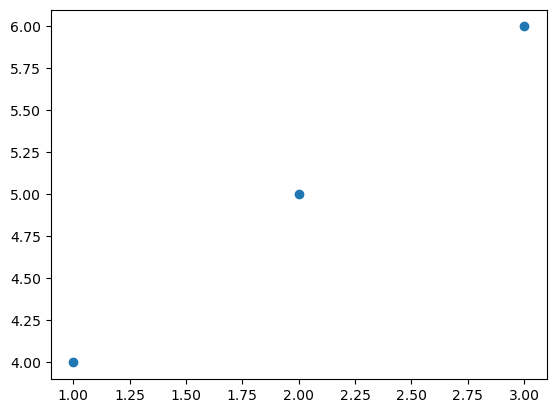

In [85]:
import matplotlib
# matplotlib 설정 객체에 강제로 _get 메서드를 심어줍니다.
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = lambda key: matplotlib.rcParams[key]

import matplotlib.pyplot as plt
%matplotlib inline

# 테스트용 그래프
plt.scatter([1, 2, 3], [4, 5, 6])
plt.show()

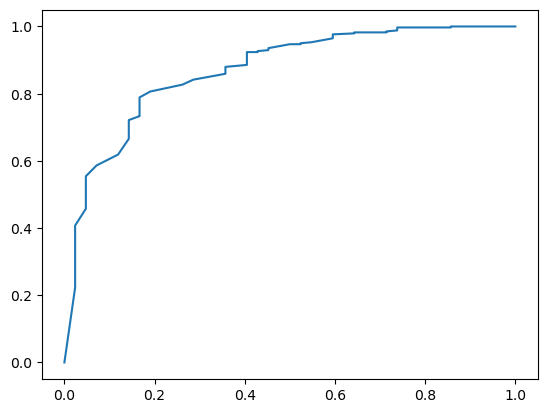

In [86]:
plt.plot(fpr, tpr)

=> 그래프가 왼쪽 위로 붙으면 붙을수록 perfect한 prediction에 가까워진다.

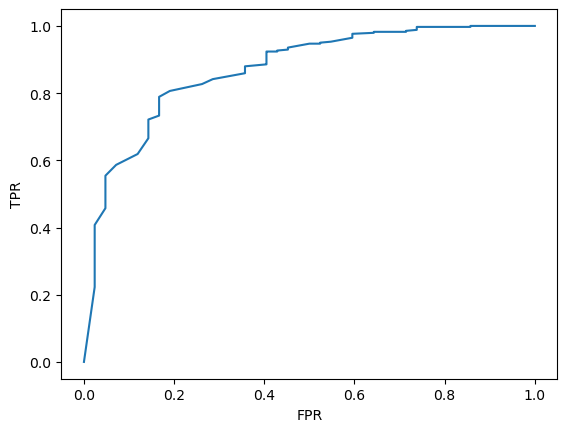

In [88]:
# X축, Y축 label 설정
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.plot(fpr, tpr)

In [89]:
print(thres)

[       inf 1.         0.994      0.99       0.98       0.972
 0.97       0.96       0.95       0.94       0.93       0.92
 0.91       0.9        0.89666667 0.89       0.88       0.87571429
 0.86       0.84       0.83       0.82       0.81       0.8
 0.79       0.78333333 0.78       0.77       0.76       0.75
 0.74       0.73       0.71       0.7075     0.7        0.69
 0.68       0.67       0.66       0.65       0.64       0.62
 0.6        0.58571429 0.54       0.52       0.5        0.43
 0.4        0.39       0.34       0.22       0.19       0.02      ]


* inf: 아무도 통과시키지 않겠다는 기준점
=> 임계값이 무한대면 어떤 샘플도 양성이 될 수 없으므로, FPR=0, TPR=0인 ROC 커브의 원즘(0,0)을 찍기 위해 설정된 가상의 값

* 값의 흐름: 엄격함 -> 관대함

* 초반부(1, ...0.994): 기준이 매우 높다. 모델이 99.4% 이상 확실할 때만 "양성"이라고 판정 (가짜 양성이 적지만, 진짜 양성도 많이 놓침)

* 중반부 (0.5): 흔히 쓰이는 기본 기준선. 50% 만 넘으로 양성으로 판정

* 후반부 (0.02) 기분이 매우 낮다. 2%의 가능성만 있어도 양성이라 판정(진짜 양성을 다 찾아내지만, 가짜 양성이 매우 많아짐)

## Area Uner the Curve 계산

In [91]:
from sklearn.metrics import roc_auc_score as AUC

In [93]:
AUC(y_test, y_score[:, 1])

0.869396732299958

## Hyperparameter 변경시 성능 변화 확인
> n_estimators = 200 으로 설정

In [94]:
modle2 = RFC(n_estimators = 200)

In [95]:
modle2.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
y_pred2 = modle2.predict(X_test)

In [98]:
f1_score(y_test, y_pred2)

0.9527896995708155

In [104]:
y_score2 = modle2.predict_proba(X_test)

In [105]:
y_score2

array([[0.005     , 0.995     ],
       [0.74      , 0.26      ],
       [0.        , 1.        ],
       [0.335     , 0.665     ],
       [0.65      , 0.35      ],
       [0.        , 1.        ],
       [0.5       , 0.5       ],
       [0.045     , 0.955     ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.08      , 0.92      ],
       [0.32      , 0.68      ],
       [0.12      , 0.88      ],
       [0.74      , 0.26      ],
       [0.005     , 0.995     ],
       [0.04      , 0.96      ],
       [0.15      , 0.85      ],
       [0.        , 1.        ],
       [0.06      , 0.94      ],
       [0.015     , 0.985     ],
       [0.225     , 0.775     ],
       [0.195     , 0.805     ],
       [0.025     , 0.975     ],
       [0.595     , 0.405     ],
       [0.27      , 0.73      ],
       [0.23      , 0.77      ],
       [0.74      , 0.26      ],
       [0.02      , 0.98      ],
       [0.        , 1.        ],
       [0.195     , 0.805     ],
       [0.

In [106]:
AUC(y_test, y_score2[:, 1])

0.8653121072475911